In [1]:
library(ArchR)
library(BSgenome.Hsapiens.UCSC.hg38)
set.seed(1)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(tidyr)
    library(purrr)
    library(data.table)
    library(reticulate)
    # plan("multicore", workers = 12)
    # options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [3]:
addArchRThreads(threads = 32) 
addArchRGenome("hg38")

Setting default number of Parallel threads to 32.

Setting default genome to Hg38.



### Load DMG atlas ATAC (matching Signac filtered cells)

In [3]:
dmg_atlas <- loadArchRProject('./ArchRSubset/')

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [13]:
use_condaenv('multi_integration')

In [14]:
sc <- import("scanpy")
adata <- sc$read_h5ad("../mosaic_integration_scglue/dmg_atac_emb_malignant_full_PEAKS.h5ad")
adata

AnnData object with n_obs × n_vars = 84494 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [15]:
# Access the cellnames
cell_names <- adata$obs_names$to_list()

# Define the pattern and replacement
pattern <- "(.*)_(.*)$"
replacement <- "\\1#\\2"

# Apply the pattern and replacement using sub
cell_names <- sub(pattern, replacement, cell_names)
head(cell_names)
tail(cell_names)

[1] "atac_T19-91014#AAACGAAAGACCCTAT-1" "atac_T19-91014#AAACGAAAGTGTAATG-1"
[3] "atac_T19-91014#AAACGAACAAATGCTC-1" "atac_T19-91014#AAACGAACACGCCGAT-1"
[5] "atac_T19-91014#AAACGAAGTACGGAGT-1" "atac_T19-91014#AAACGAAGTATCCCTC-1"

[1] "multiome_P-6774_S-10146#TTTGTGGCATTATGAC-1"
[2] "multiome_P-6774_S-10146#TTTGTGTTCCTAGTAA-1"
[3] "multiome_P-6774_S-10146#TTTGTTGGTAGGATTT-1"
[4] "multiome_P-6774_S-10146#TTTGTTGGTTGGATAT-1"
[5] "multiome_P-6774_S-10146#TTTGTTGGTTGTAACG-1"
[6] "multiome_P-6774_S-10146#TTTGTTGGTTTATCGC-1"

In [16]:
idx <- BiocGenerics::which(dmg_atlas$cellNames %in% cell_names)
head(idx)
length(idx)

[1] 1 2 3 4 5 6

[1] 83921

In [17]:
setdiff(cell_names, dmg_atlas$cellNames)

[1] "atac_T19-91014#AAGGAGCGTACGAGAC-1"         
  [2] "atac_T19-91014#ACTAACGGTAAGTGCG-1"         
  [3] "atac_T19-91014#AGATAGAAGGTACTCT-1"         
  [4] "atac_T19-91014#AGTTACGTCTCTGACC-1"         
  [5] "atac_T19-91014#ATAGGCTCAGCCGAAA-1"         
  [6] "atac_T19-91014#CACTAAGGTTACCCAA-1"         
  [7] "atac_T19-91014#CAGCTGGAGGGTGTTG-1"         
  [8] "atac_T19-91014#CTACAGATCGTGAGTT-1"         
  [9] "atac_T19-91014#CTCAGAAGTCATCGTA-1"         
 [10] "atac_T19-91014#CTGGGACAGAACGCCA-1"         
 [11] "atac_T19-91014#GAAATGATCTTTGCAT-1"         
 [12] "atac_T19-91014#GAACCGCAGTCGTACT-1"         
 [13] "atac_T19-91014#GACCTTCTCATCATGG-1"         
 [14] "atac_T19-91014#GCACGGTAGTTACACC-1"         
 [15] "atac_T19-91014#GCCAGCAGTGCCCGAT-1"         
 [16] "atac_T19-91014#GCGATCGTCTTCCACG-1"         
 [17] "atac_T19-91014#GCTCAGGCAAGTCTCA-1"         
 [18] "atac_T19-91014#GGCATTAGTAACGGTG-1"         
 [19] "atac_T19-91014#GGTAGGAGTAGGTAAT-1"         
 [20] "atac_T19-91014#GTAATCGCATCCGTAA-1"         
 [21] "atac_T19-91014#GTCACTCTCTATACCT-1"         
 [22] "atac_T19-91014#GTGCCAGAGTCCGGAA-1"         
 [23] "atac_T19-91014#TAACTTCGTCTAAGAA-1"         
 [24] "atac_T19-91014#TACATGGCATCCGTGG-1"         
 [25] "atac_T19-91014#TACGGATCAGCGTAGA-1"         
 [26] "atac_T19-91014#TAGCCCTAGCACCATT-1"         
 [27] "atac_T19-91014#TAGCCGGGTCATGAGG-1"         
 [28] "atac_T19-91014#TAGGAGGCACAGTTCA-1"         
 [29] "atac_T19-91014#TATCGAGGTGGTACTT-1"         
 [30] "atac_T19-91014#TCCATCGAGAACGACC-1"         
 [31] "atac_T19-91014#TCCATCGTCGGTGATT-1"         
 [32] "atac_T19-91014#TGCTCACGTGGAAGCT-1"         
 [33] "atac_T19-91014#TGGCCTTAGTCCAGAG-1"         
 [34] "atac_T19-91014#TTAGCTTCAGGAGCAT-1"         
 [35] "atac_T20-90296#CCAGATACAAACCTAC-1"         
 [36] "atac_T20-90296#GAAAGTAAGAGCCTGA-1"         
 [37] "atac_T20-90296#TGCTATTGTGGCATAG-1"         
 [38] "atac_T20-90296#TTACGTTAGGAACCGT-1"         
 [39] "atac_T20-90296#TTGTTGTTCGAGGTCC-1"         
 [40] "atac_T20-90296#TTTGAGGAGCCGCAAA-1"         
 [41] "atac_MUV1#AAAGATGGTCTGATTG-1"              
 [42] "atac_MUV1#GTCTACCCACGCGCAT-1"              
 [43] "atac_MUV1#GTGTCCTCACACATTG-1"              
 [44] "atac_P-1764_S-1766#AAACGAAAGCTAACAA-1"     
 [45] "atac_P-1764_S-1766#AAACTCGTCCGTGCAG-1"     
 [46] "atac_P-1764_S-1766#AAAGATGAGCCCATTA-1"     
 [47] "atac_P-1764_S-1766#AACGAGGCACTGTCGG-1"     
 [48] "atac_P-1764_S-1766#AACTTGGGTTTGGATC-1"     
 [49] "atac_P-1764_S-1766#AATGCCAGTACGGTTT-1"     
 [50] "atac_P-1764_S-1766#AATGTCGCAGGCTACC-1"     
 [51] "atac_P-1764_S-1766#ACCATCCAGTTACACC-1"     
 [52] "atac_P-1764_S-1766#ACCGAATAGGGCGAAG-1"     
 [53] "atac_P-1764_S-1766#ACCGCAGCAGAGAGAA-1"     
 [54] "atac_P-1764_S-1766#AGACAAATCGTCGCAG-1"     
 [55] "atac_P-1764_S-1766#AGCCGCATCGTCCCTA-1"     
 [56] "atac_P-1764_S-1766#AGGCCTGTCTGGTACA-1"     
 [57] "atac_P-1764_S-1766#ATGTCGACAATGATGA-1"     
 [58] "atac_P-1764_S-1766#CACCTTGAGTCGGGAT-1"     
 [59] "atac_P-1764_S-1766#CAGTATGGTACTTGAC-1"     
 [60] "atac_P-1764_S-1766#CCCTAACTCACTCGGG-1"     
 [61] "atac_P-1764_S-1766#CCTTAATAGTCGGGAT-1"     
 [62] "atac_P-1764_S-1766#CGTAAACGTGAATGTA-1"     
 [63] "atac_P-1764_S-1766#CTCTCGAGTACTTGAC-1"     
 [64] "atac_P-1764_S-1766#GATGATCTCTGGCACG-1"     
 [65] "atac_P-1764_S-1766#GCAGCCATCAGTCACA-1"     
 [66] "atac_P-1764_S-1766#GCCCAGATCCGGGCAT-1"     
 [67] "atac_P-1764_S-1766#GCGAGTCTCTCTATCA-1"     
 [68] "atac_P-1764_S-1766#GCGTAGCTCCTCCATG-1"     
 [69] "atac_P-1764_S-1766#GCGTTGGCACTGCTCT-1"     
 [70] "atac_P-1764_S-1766#GCTCAGGCAGTTGCAT-1"     
 [71] "atac_P-1764_S-1766#GGCGAAACAAAGGAAG-1"     
 [72] "atac_P-1764_S-1766#GGTCATACAGATAAGT-1"     
 [73] "atac_P-1764_S-1766#GTACTTTAGGTACATA-1"     
 [74] "atac_P-1764_S-1766#GTAGACTTCATCATGG-1"     
 [75] "atac_P-1764_S-1766#GTCACGGGTCATAAGA-1"     
 [76] "atac_P-1764_S-1766#GTGCCAGTCCTTCGAC-1"     
 [77] "atac_P-1764_S-1766#GTGTCAATCTACTTTG-1"     
 [78] "atac_P-1764_S-1766#GTTATTCCATAGCAGG-1"     
 [79] "atac_P-1764_S-176

In [18]:
sample(setdiff(cell_names, dmg_atlas$cellNames), size = 200)

[1] "GNG_region_11#TGGAACAAGGTAACGA-1"          
  [2] "GNG_region_11#AGACACGCAGCTTACA-1"          
  [3] "GNG_region_11#TCCTTTACAGCAGGTA-1"          
  [4] "GNG_region_11#GTTAACCAGTTATCCT-1"          
  [5] "GNG_region_11#TCCTTCAAGGACGTAA-1"          
  [6] "atac_P-2687_S-2688#CCAGAATGTTTAGGAA-1"     
  [7] "multiome_P-6640_S-9581#TCACCTGGTCTTTGAC-1" 
  [8] "GNG_region_11#TTAAGTGTCTCCATGC-1"          
  [9] "GNG_region_11#CCAGCTAAGTAACCCG-1"          
 [10] "atac_P-6255_S-8500#CTGGCAGTCATCATGG-1"     
 [11] "atac_P-2687_S-2688#CACCTTGAGCCGCAAA-1"     
 [12] "multiome_P-6774_S-10146#TCTACCTCAATAGCAA-1"
 [13] "atac_P-2687_S-2688#ATGTTTCCATATTGGC-1"     
 [14] "multiome_P-1779_S-1781#AAACCGCGTTAAGGTT-1" 
 [15] "atac_P-2687_S-2688#CAGGATTGTGTCCAGC-1"     
 [16] "GNG_region_11#TTTGACTTCCGTAAAC-1"          
 [17] "atac_P-1764_S-1766#CACCTTGAGTCGGGAT-1"     
 [18] "GNG_region_11#TGAGCTTAGGATCCGC-1"          
 [19] "multiome_P-6640_S-9581#ATTGAAGCAACCTAAT-1" 
 [20] "atac_P-2687_S-2688#TATGTGGAGGTTAACA-1"     
 [21] "GNG_region_11#ACGATTCAGCCACAAT-1"          
 [22] "multiome_P-6640_S-9581#CTCATGACAGCTTAGC-1" 
 [23] "GNG_region_11#GTTACAGGTGGAGCAA-1"          
 [24] "atac_P-2687_S-2688#CCTATTACACCCTTTG-1"     
 [25] "atac_P-1764_S-1766#ACCGAATAGGGCGAAG-1"     
 [26] "GNG_region_11#ACATTGCAGCATTATG-1"          
 [27] "GNG_region_11#CACAGGGAGACTTACA-1"          
 [28] "GNG_region_11#TTTGCGACACATTAAC-1"          
 [29] "GNG_region_11#TTAGCAATCTTGGACG-1"          
 [30] "GNG_region_11#TGATCAATCCGCACAA-1"          
 [31] "multiome_P-1764_S-1766#GGGCATGAGGAGGTTA-1" 
 [32] "GNG_region_11#TTGCCCGTCCCGTTTA-1"          
 [33] "GNG_region_11#TTGGCTTGTAGTTAAC-1"          
 [34] "GNG_region_11#TAGCGGCTCAATCTAG-1"          
 [35] "atac_P-2687_S-2688#TTGCACCTCCAGTACA-1"     
 [36] "atac_P-2687_S-2688#TTTGGCCTCGGCTATA-1"     
 [37] "atac_P-2687_S-2688#GGATAGGAGATGTTGA-1"     
 [38] "atac_P-2687_S-2688#CTGTATTGTCCGTCGA-1"     
 [39] "atac_P-1764_S-1766#GATGATCTCTGGCACG-1"     
 [40] "GNG_region_11#TGGCCTGCACTGGCCA-1"          
 [41] "GNG_region_11#TATGGCCCAGGCGATA-1"          
 [42] "GNG_region_11#TCATGTTTCTTACTCG-1"          
 [43] "atac_P-6253_S-8498#TGGCCTTAGGCGTCCT-1"     
 [44] "atac_P-6255_S-8500#CTCAGCTGTTACCCAA-1"     
 [45] "atac_P-2687_S-2688#CCGTAGGCATCTCACC-1"     
 [46] "GNG_region_11#TTGATGTCACCCTCAC-1"          
 [47] "GNG_region_11#TATATCCTCCTGGTCT-1"          
 [48] "GNG_region_11#CTGACATAGGACGTAA-1"          
 [49] "GNG_region_11#TTATCCTAGCCTGACA-1"          
 [50] "GNG_region_11#TCCTTAGTCATCCACC-1"          
 [51] "GNG_region_11#TATGACTCATTGGGAG-1"          
 [52] "GNG_region_11#AATCTCAAGCCGCTAA-1"          
 [53] "atac_P-1764_S-1766#TTCGGTCGTGGCCTTG-1"     
 [54] "GNG_region_11#GTTCGCGCACATAACT-1"          
 [55] "GNG_region_11#TGGCCAATCCCGCATT-1"          
 [56] "GNG_region_11#GTCCATTGTAGTTGGC-1"          
 [57] "GNG_region_11#TTGCACACAAGCTACC-1"          
 [58] "GNG_region_11#GGAGGTTAGCTAAGTC-1"          
 [59] "atac_P-2687_S-2688#TAGCCCTTCCGATTGA-1"     
 [60] "GNG_region_11#TTAGTCAAGACTTATG-1"          
 [61] "atac_T19-91014#GCGATCGTCTTCCACG-1"         
 [62] "multiome_P-1780_S-1780#TGTAAAGCAGAGAGCC-1" 
 [63] "atac_P-1764_S-1766#ATGTCGACAATGATGA-1"     
 [64] "atac_P-1764_S-1766#CCCTAACTCACTCGGG-1"     
 [65] "multiome_P-6640_S-9581#ACGTTACAGGATTGAG-1" 
 [66] "atac_P-2687_S-2688#GCACGCAGTCTGGATT-1"     
 [67] "multiome_P-6640_S-9581#AGCAGGTAGGACCTTG-1" 
 [68] "atac_T19-91014#TTAGCTTCAGGAGCAT-1"         
 [69] "atac_P-2687_S-2688#GTAGACTCAGTTGCAT-1"     
 [70] "atac_P-1764_S-1766#GTTATTCCATAGCAGG-1"     
 [71] "atac_P-2687_S-2688#CACAGATTCCCGATTC-1"     
 [72] "GNG_region_11#GTTCTTAGTGGAGCAA-1"          
 [73] "atac_T19-91014#GGCATTAGTAACGGTG-1"         
 [74] "GNG_region_11#TGTATCCGTGCTCCGT-1"          
 [75] "atac_P-1764_S-1766#GCGTAGCTCCTCCATG-1"     
 [76] "multiome_P-6640_S-9581#GGCAAGCCACAACCTA-1" 
 [77] "atac_T19-91014#TCCATCGAGAACGACC-1"         
 [78] "GNG_region_11#ATTAGTCCAGGTTATT-1"          
 [79] "GNG_region_11#TTT

In [19]:
# missing cells are due to the raw processing made in Signac creating a common peakset
# ArchR reads the fragments from CellRanger and tehre might be slight discrenpacies
# in the cells included
length(setdiff(cell_names, dmg_atlas$cellNames))

[1] 573

In [20]:
cellsAtlas <- dmg_atlas$cellNames[idx]
head(cellsAtlas)

[1] "atac_MUV1#CCCTAACCATGGAGGT-1" "atac_MUV1#GGGTCTGTCGGAGTTT-1"
[3] "atac_MUV1#GTGTCCTGTGAGTCGA-1" "atac_MUV1#AGCTGATCATGTATCG-1"
[5] "atac_MUV1#GTGTCAAGTATCGCGC-1" "atac_MUV1#CAAAGCTCAGCGTGAA-1"

In [21]:
# to avoid any errors (Error in .Call2("map_positions", run_lens, pos, method, PACKAGE = "S4Vectors"): subscript contains NAs)
# the exact name of cells must be inside the archr object
# addditonal cell names will lead to the error above 
# also see https://github.com/GreenleafLab/ArchR/issues/212

malignant <- subsetArchRProject(
  ArchRProj = dmg_atlas,
  cells = cellsAtlas,
  outputDirectory = "ArchR_malignant_v2",
  dropCells = TRUE,
  logFile = NULL,
  force = FALSE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_v2

Copying Arrow Files...

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 9): Annotations

Copying Other Files (2 of 9): Background-Peaks.rds

Copying Other Files (3 of 9): Embeddings

Copying Other Files (4 of 9): GroupCoverages

Copying Other Files (5 of 9): IterativeLSI

Copying Other Files (6 of 9): Peak2GeneLinks

Copying Other Files (7 of 9): PeakCalls

Copying Other Files (8 of 9): Plots

Copying Other Files (9 of 9): RNAIntegration

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\       

In [14]:
malignant <- addGroupCoverages(ArchRProj = malignant, groupBy = "MPv2", force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-c47962e4e9339-Date-2024-08-14_Time-13-52-12.676544.log
If there is an issue, please report to github with logFile!

C1_RGLike (1 of 10) : CellGroups N = 5

C2_TriIPCLike (2 of 10) : CellGroups N = 5

C3_IPCLike (3 of 10) : CellGroups N = 5

C4_OPCLike (4 of 10) : CellGroups N = 5

C5_COPLike (5 of 10) : CellGroups N = 3

C6_ACLike (6 of 10) : CellGroups N = 5

C7_CiliaLike (7 of 10) : CellGroups N = 4

C8_TDLike (8 of 10) : CellGroups N = 5

C9_GWLike (9 of 10) : CellGroups N = 5

C10_GBLike (10 of 10) : CellGroups N = 5

2024-08-14 13:52:26.55925 : Creating Coverage Files!, 0.231 mins elapsed.

2024-08-14 13:52:26.563073 : Batch Execution w/ safelapply!, 0.231 mins elapsed.

2024-08-14 13:59:15.799546 : Adding Kmer Bias to Coverage Files!, 7.052 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bias (1 of 47)

Adding Kmer Bias (2 of 47)

Adding Kmer Bias (3 of 47)

Adding Kmer Bias (4 of 47)

Adding Kmer Bias (5 of 47)

Ad

### Marker peaks against Archr references

In [12]:
enrichATAC <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "ATAC",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-d97c0baf0738-Date-2024-08-14_Time-15-21-34.log
If there is an issue, please report to github with logFile!

2024-08-14 15:21:55 : Computing Enrichments 1 of 10, 0.355 mins elapsed.

2024-08-14 15:21:55 : Computing Enrichments 2 of 10, 0.358 mins elapsed.

2024-08-14 15:21:55 : Computing Enrichments 3 of 10, 0.361 mins elapsed.

2024-08-14 15:21:56 : Computing Enrichments 4 of 10, 0.369 mins elapsed.

2024-08-14 15:21:56 : Computing Enrichments 5 of 10, 0.372 mins elapsed.

2024-08-14 15:21:56 : Computing Enrichments 6 of 10, 0.376 mins elapsed.

2024-08-14 15:21:56 : Computing Enrichments 7 of 10, 0.379 mins elapsed.

2024-08-14 15:21:57 : Computing Enrichments 8 of 10, 0.382 mins elapsed.

2024-08-14 15:21:57 : Computing Enrichments 9 of 10, 0.387 mins elapsed.

2024-08-14 15:21:57 : Computing Enrichments 10 of 10, 0.389 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-d97c0baf0738-Date-2024-08-14_Tim

In [13]:
heatmapATAC <- plotEnrichHeatmap(enrichATAC, n = 7, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-d97c051149faa-Date-2024-08-14_Time-15-21-58.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



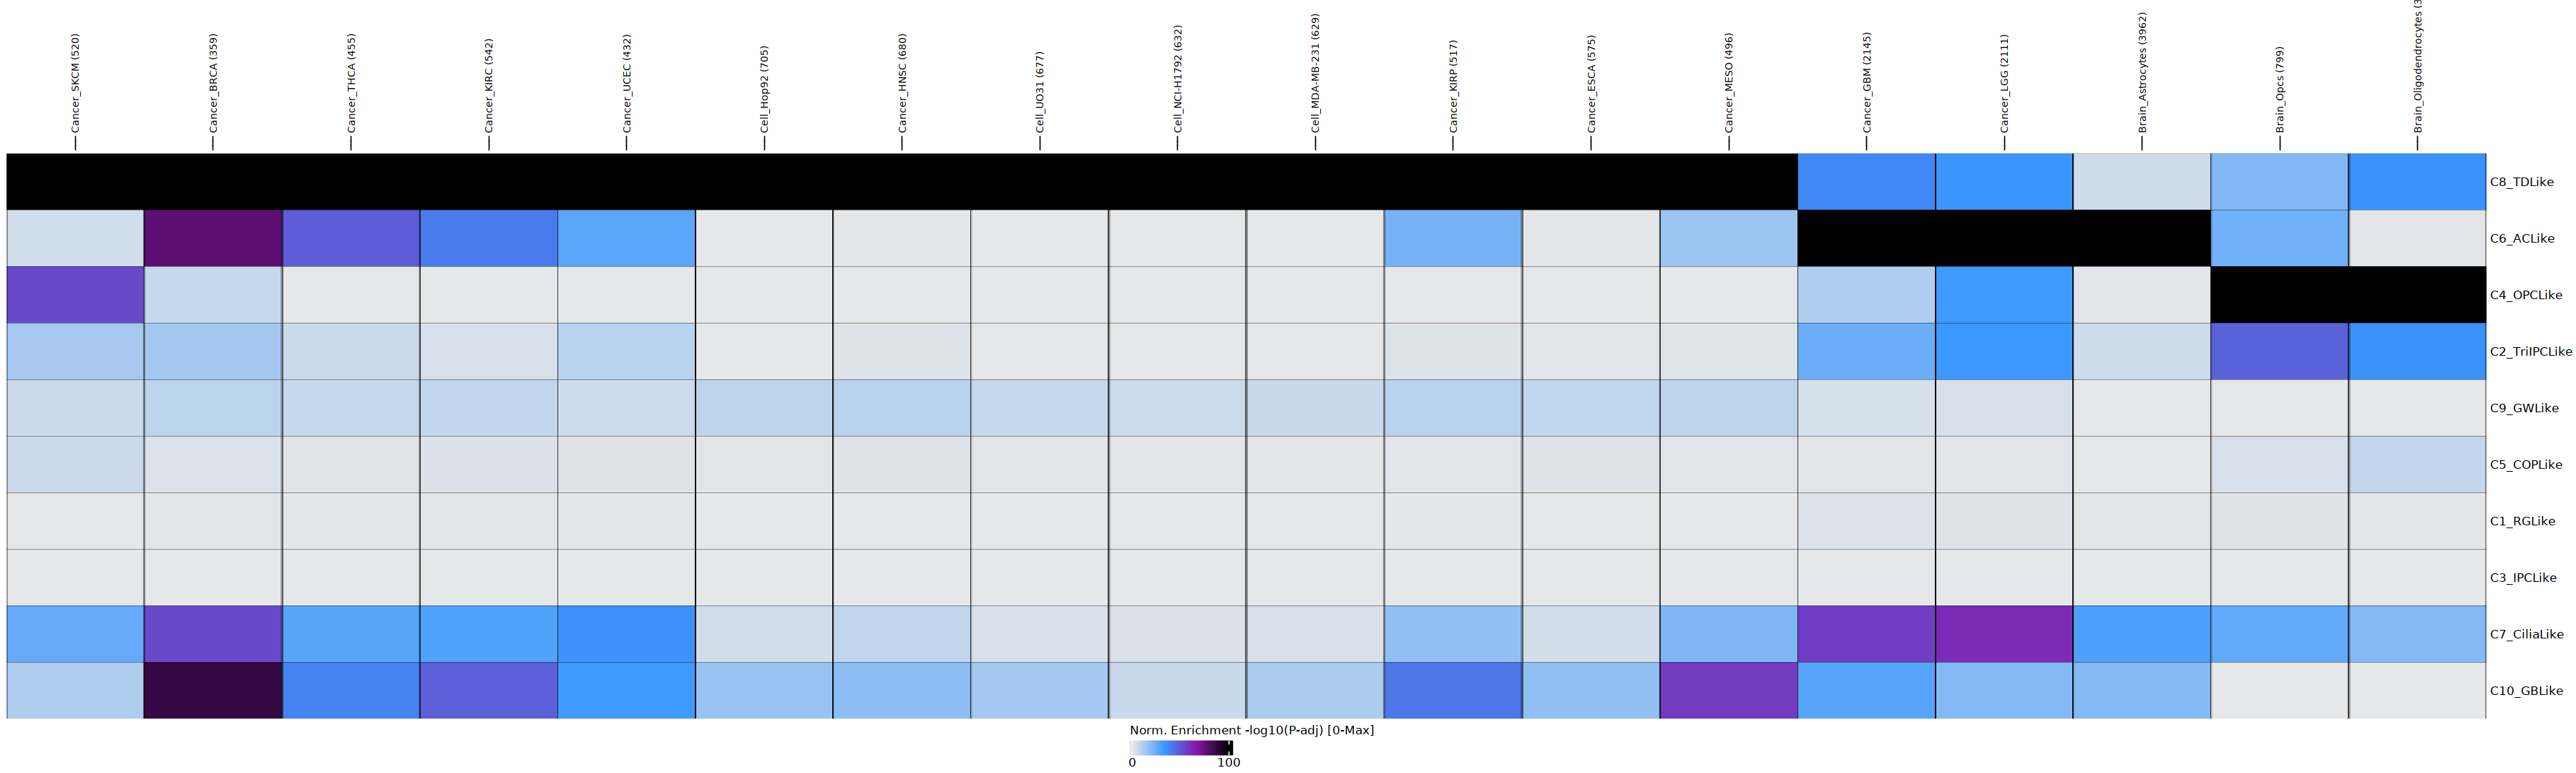

In [14]:
ComplexHeatmap::draw(heatmapATAC, heatmap_legend_side = "bot", annotation_legend_side = "bot")

### Exploring Mannens peaks against DMG atlas

In [4]:
malignant <- loadArchRProject('./ArchR_malignant_v2/')
malignant

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

class: ArchRProject 
outputDirectory: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_v2 
samples(21): multiome_P-1709_S-1709 multiome_P-1701_S-1701 ...
  atac_P-2687_S-2688 atac_P-6255_S-8500
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... FRIP MPv2
numberOfCells(1): 83921
medianTSS(1): 8.532
medianFrags(1): 11219

In [5]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = malignant, 
    useMatrix = "PeakMatrix", 
    groupBy = "MPv2",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
     maxCells = 2500
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1c05fb6533c8d7-Date-2024-09-06_Time-18-28-45.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2024-09-06 18:28:48 : Matching Known Biases, 0.043 mins elapsed.

###########
2024-09-06 18:30:56 : Completed Pairwise Tests, 2.18 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-1c05fb6533c8d7-Date-2024-09-06_Time-18-28-45.log



In [6]:
markersPeaks

class: SummarizedExperiment 
dim: 554165 10 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(554165): 1 2 ... 554164 554165
rowData names(4): seqnames idx start end
colnames(10): C1_RGLike C2_TriIPCLike ... C9_GWLike C10_GBLike
colData names(0):

In [7]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeaks, 
  cutOff = "FDR <= 0.1 & Log2FC >= 0.5",
  transpose = TRUE
)

Warning message:
“'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated")”
ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-25af951c15ae5e-Date-2024-09-05_Time-19-43-03.log
If there is an issue, please report to github with logFile!

Identified 187015 markers!



  [1] "chr1:2539315-2539815"     "chr1:16900699-16901199"  
  [3] "chr1:22611416-22611916"   "chr1:24730437-24730937"  
  [5] "chr1:27971059-27971559"   "chr1:41689072-41689572"  
  [7] "chr1:46681343-46681843"   "chr1:47726196-47726696"  
  [9] "chr1:50110136-50110636"   "chr1:103526067-103526567"
 [11] "chr1:108847558-108848058" "chr1:108948047-108948547"
 [13] "chr1:110606276-110606776" "chr1:145280954-145281454"
 [15] "chr1:156404264-156404764" "chr1:905216-905716"      
 [17] "chr1:944201-944701"       "chr1:1001157-1001657"    
 [19] "chr1:1299520-1300020"     "chr1:1304602-1305102"    
 [21] "chr1:1433659-1434159"     "chr1:2025579-2026079"    
 [23] "chr1:2060080-2060580"     "chr1:2181733-2182233"    
 [25] "chr1:2195349-2195849"     "chr1:2204066-2204566"    
 [27] "chr1:2419594-2420094"     "chr1:2585318-2585818"    
 [29] "chr1:2983313-2983813"     "chr1:3011083-3011583"    
 [31] "chr1:2467161-2467661"     "chr1:2498702-2499202"    
 [33] "chr1:2913161-2913661"     "chr1:3

Adding Annotations..

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-25af951c15ae5e-Date-2024-09-05_Time-19-43-03.log



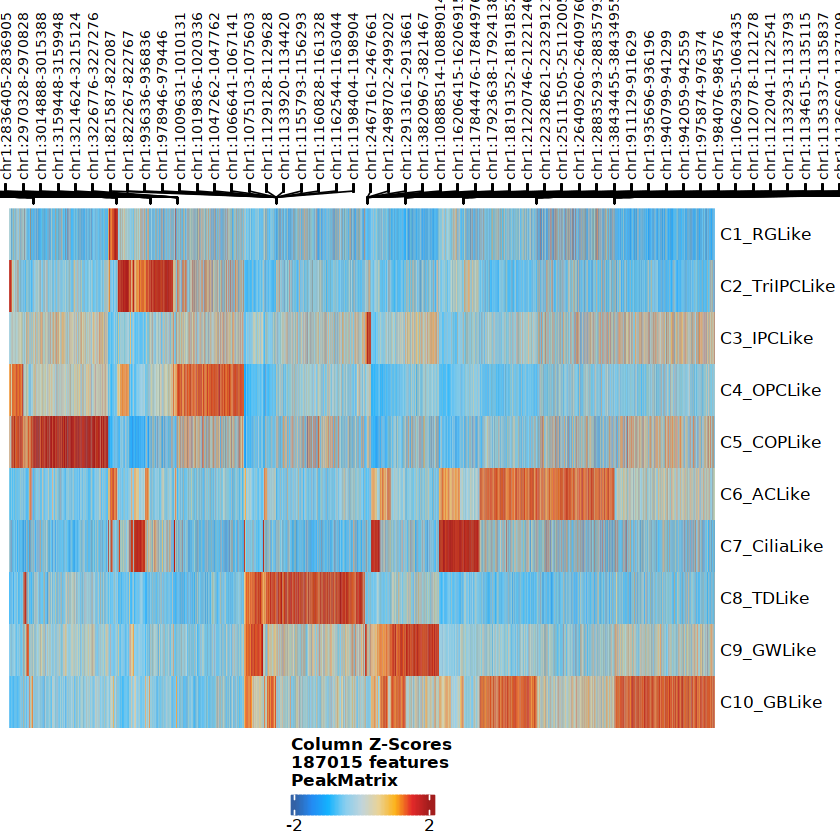

In [8]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [9]:
library(data.table)
library(GenomicRanges)
library(future)
library(future.apply)

# Define the directory containing your .tsv.gz files
tsv_dir <- "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/pycistopic_fetal/pseudobulk_bed_files"

# List your .tsv.gz files
tsv_files <- list.files(tsv_dir, pattern = "*.tsv.gz", full.names = TRUE)

# Create a named list, removing the directory and extension
CustomPeaks <- setNames(tsv_files, sub(".*/(.*).fragments.tsv.gz$", "\\1", tsv_files))

# Plan to use multiple cores
plan(multisession, workers = 32)

# Parallel file processing
CustomPeaksGR <- future_lapply(CustomPeaks, function(tsv_file) {
  df <- fread(cmd = paste("zcat", tsv_file), col.names = c("chr", "start", "end", "barcode", "score"), nThread = 32)
  df[, name := paste0(chr, ":", start, "-", end)]
  df[, strand := "+"]
  df[, barcode := NULL]
  gr <- makeGRangesFromDataFrame(df, keep.extra.columns = TRUE)
  return(gr)
})

In [10]:
malignant <- addPeakAnnotations(ArchRProj = malignant, regions = CustomPeaksGR, name = "fetal")

ArchR logging to : ArchRLogs/ArchR-addPeakAnnotations-25af95f22d094-Date-2024-09-05_Time-20-23-44.log
If there is an issue, please report to github with logFile!

2024-09-05 20:27:19 : Creating Peak Overlap Matrix, 3.584 mins elapsed.

2024-09-05 20:39:02 : All Regions Overlap at least 1 peak!, 15.309 mins elapsed.



In [11]:
enrichRegions <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "fetal",
    cutOff = "FDR <= 0.2 & Log2FC >= 0.25"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-25af95772f8e60-Date-2024-09-05_Time-20-43-31.log
If there is an issue, please report to github with logFile!

2024-09-05 20:43:50 : Computing Enrichments 1 of 10, 0.313 mins elapsed.

2024-09-05 20:43:50 : Computing Enrichments 2 of 10, 0.32 mins elapsed.

2024-09-05 20:43:51 : Computing Enrichments 3 of 10, 0.326 mins elapsed.

2024-09-05 20:43:51 : Computing Enrichments 4 of 10, 0.332 mins elapsed.

2024-09-05 20:43:51 : Computing Enrichments 5 of 10, 0.339 mins elapsed.

2024-09-05 20:43:52 : Computing Enrichments 6 of 10, 0.345 mins elapsed.

2024-09-05 20:43:52 : Computing Enrichments 7 of 10, 0.353 mins elapsed.

2024-09-05 20:43:53 : Computing Enrichments 8 of 10, 0.36 mins elapsed.

2024-09-05 20:43:53 : Computing Enrichments 9 of 10, 0.367 mins elapsed.

2024-09-05 20:43:53 : Computing Enrichments 10 of 10, 0.373 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-25af95772f8e60-Date-2024-09-05_T

In [12]:
enrichRegions

class: SummarizedExperiment 
dim: 25 10 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(25): COP Endothelial ... Roof_plate Schwann
rowData names(0):
colnames(10): C1_RGLike C2_TriIPCLike ... C9_GWLike C10_GBLike
colData names(0):

In [13]:
heatmapRegions <- plotEnrichHeatmap(enrichRegions, n = 135, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-25af956869c402-Date-2024-09-05_Time-20-43-54.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



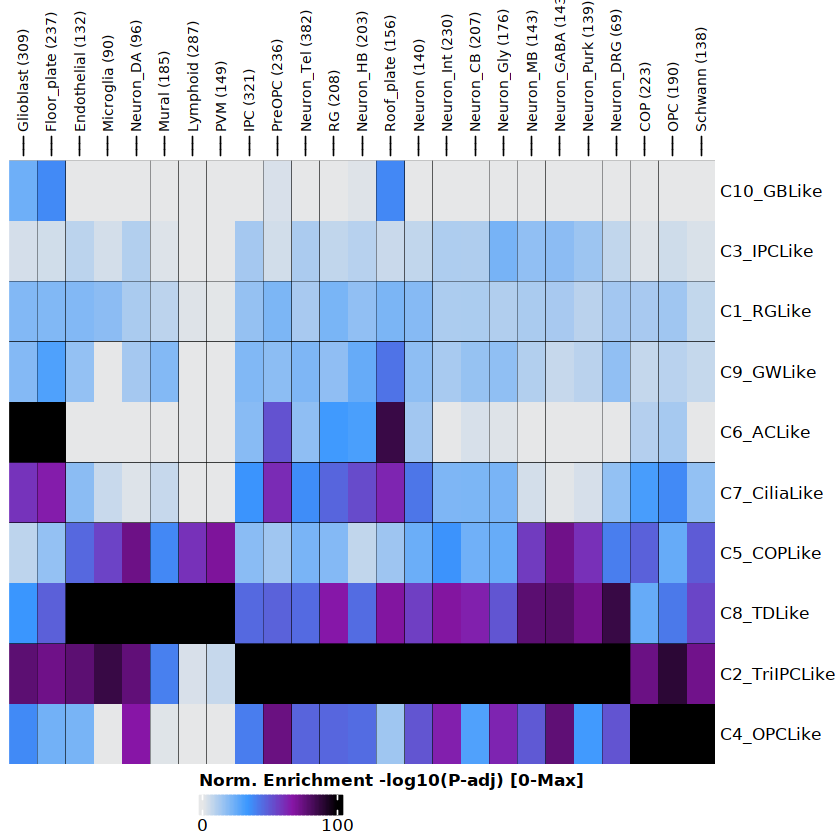

In [14]:
ComplexHeatmap::draw(heatmapRegions, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [ ]:
library(data.table)
library(GenomicRanges)
library(future)
library(future.apply)

# Define the directory containing your .tsv.gz files
tsv_dir <- "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/pycistopic_fetal/pseudobulk_bed_files/glial"

# List your .tsv.gz files
tsv_files <- list.files(tsv_dir, pattern = "*.tsv.gz", full.names = TRUE)

# Create a named list, removing the directory and extension
CustomPeaks <- setNames(tsv_files, sub(".*/(.*).fragments.tsv.gz$", "\\1", tsv_files))

# Plan to use multiple cores
plan(multisession, workers = 48)

# Parallel file processing
CustomPeaksGR <- future_lapply(CustomPeaks, function(tsv_file) {
  df <- fread(cmd = paste("zcat", tsv_file), col.names = c("chr", "start", "end", "barcode", "score"), nThread = 48)
  df[, name := paste0(chr, ":", start, "-", end)]
  df[, strand := "+"]
  df[, barcode := NULL]
  gr <- makeGRangesFromDataFrame(df, keep.extra.columns = TRUE)
  return(gr)
})

In [ ]:
malignant <- addPeakAnnotations(ArchRProj = malignant, regions = CustomPeaksGR, name = "fetal")

ArchR logging to : ArchRLogs/ArchR-addPeakAnnotations-1c05fb6d8eafb1-Date-2024-09-06_Time-18-41-20.log
If there is an issue, please report to github with logFile!

2024-09-06 18:45:29 : Creating Peak Overlap Matrix, 4.153 mins elapsed.

2024-09-06 18:47:16 : All Regions Overlap at least 1 peak!, 5.946 mins elapsed.



In [ ]:
enrichRegions <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "fetal",
    cutOff = "FDR <= 0.2 & Log2FC >= 0.25"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-1c05fb5d645d32-Date-2024-09-06_Time-18-48-35.log
If there is an issue, please report to github with logFile!

2024-09-06 18:48:58 : Computing Enrichments 1 of 10, 0.385 mins elapsed.

2024-09-06 18:48:58 : Computing Enrichments 2 of 10, 0.387 mins elapsed.

2024-09-06 18:48:58 : Computing Enrichments 3 of 10, 0.39 mins elapsed.

2024-09-06 18:48:58 : Computing Enrichments 4 of 10, 0.392 mins elapsed.

2024-09-06 18:49:19 : Computing Enrichments 5 of 10, 0.74 mins elapsed.

2024-09-06 18:49:19 : Computing Enrichments 6 of 10, 0.743 mins elapsed.

2024-09-06 18:49:20 : Computing Enrichments 7 of 10, 0.746 mins elapsed.

2024-09-06 18:49:20 : Computing Enrichments 8 of 10, 0.748 mins elapsed.

2024-09-06 18:49:20 : Computing Enrichments 9 of 10, 0.751 mins elapsed.

2024-09-06 18:49:20 : Computing Enrichments 10 of 10, 0.754 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-1c05fb5d645d32-Date-2024-09-06_T

In [ ]:
heatmapRegions <- plotEnrichHeatmap(enrichRegions, n = 135, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-1c05fb15795ce1-Date-2024-09-06_Time-18-49-21.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



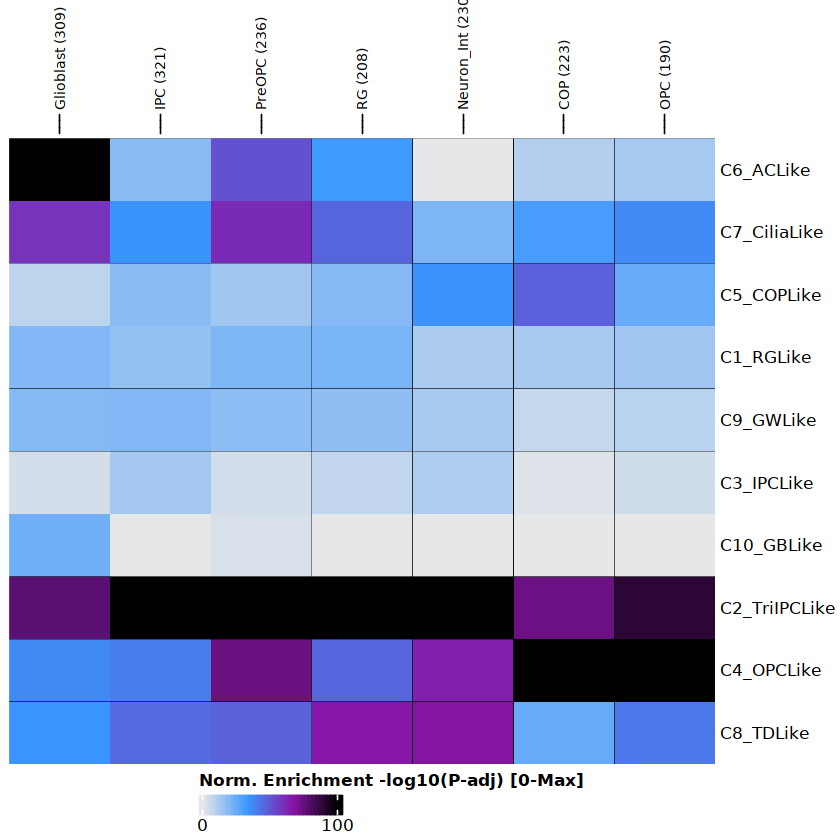

In [ ]:
ComplexHeatmap::draw(heatmapRegions, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [5]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = malignant, 
    useMatrix = "PeakMatrix", 
    groupBy = "MPv2",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
     maxCells = 5000
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1c499a5d8b6325-Date-2024-09-06_Time-19-09-23.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2024-09-06 19:09:25 : Matching Known Biases, 0.032 mins elapsed.

###########
2024-09-06 19:11:58 : Completed Pairwise Tests, 2.585 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-1c499a5d8b6325-Date-2024-09-06_Time-19-09-23.log



In [6]:
library(data.table)
library(GenomicRanges)
library(future)
library(future.apply)

# Define the directory containing your .tsv.gz files
tsv_dir <- "/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/pycistopic_fetal/pseudobulk_bed_files/glial"

# List your .tsv.gz files
tsv_files <- list.files(tsv_dir, pattern = "*.tsv.gz", full.names = TRUE)

# Create a named list, removing the directory and extension
CustomPeaks <- setNames(tsv_files, sub(".*/(.*).fragments.tsv.gz$", "\\1", tsv_files))

# Plan to use multiple cores
plan(multisession, workers = 48)

# Parallel file processing
CustomPeaksGR <- future_lapply(CustomPeaks, function(tsv_file) {
  df <- fread(cmd = paste("zcat", tsv_file), col.names = c("chr", "start", "end", "barcode", "score"), nThread = 48)
  df[, name := paste0(chr, ":", start, "-", end)]
  df[, strand := "+"]
  df[, barcode := NULL]
  gr <- makeGRangesFromDataFrame(df, keep.extra.columns = TRUE)
  return(gr)
})

In [7]:
malignant <- addPeakAnnotations(ArchRProj = malignant, regions = CustomPeaksGR, name = "fetal")

ArchR logging to : ArchRLogs/ArchR-addPeakAnnotations-1c499a248da9ea-Date-2024-09-06_Time-19-22-05.log
If there is an issue, please report to github with logFile!

2024-09-06 19:26:32 : Creating Peak Overlap Matrix, 4.464 mins elapsed.

2024-09-06 19:28:39 : All Regions Overlap at least 1 peak!, 6.578 mins elapsed.



In [8]:
enrichRegions <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "fetal",
    cutOff = "FDR <= 0.2 & Log2FC >= 0.25"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-1c499a68a85531-Date-2024-09-06_Time-19-29-58.log
If there is an issue, please report to github with logFile!

2024-09-06 19:30:21 : Computing Enrichments 1 of 10, 0.38 mins elapsed.

2024-09-06 19:30:21 : Computing Enrichments 2 of 10, 0.383 mins elapsed.

2024-09-06 19:30:21 : Computing Enrichments 3 of 10, 0.385 mins elapsed.

2024-09-06 19:30:21 : Computing Enrichments 4 of 10, 0.388 mins elapsed.

2024-09-06 19:30:21 : Computing Enrichments 5 of 10, 0.391 mins elapsed.

2024-09-06 19:30:21 : Computing Enrichments 6 of 10, 0.394 mins elapsed.

2024-09-06 19:30:22 : Computing Enrichments 7 of 10, 0.398 mins elapsed.

2024-09-06 19:30:22 : Computing Enrichments 8 of 10, 0.4 mins elapsed.

2024-09-06 19:30:22 : Computing Enrichments 9 of 10, 0.404 mins elapsed.

2024-09-06 19:30:22 : Computing Enrichments 10 of 10, 0.407 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-1c499a68a85531-Date-2024-09-06_Ti

In [ ]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = malignant, 
    useMatrix = "PeakMatrix", 
    groupBy = "MPv2",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-1c499a1275c879-Date-2024-09-06_Time-21-18-22.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2024-09-06 21:18:24 : Matching Known Biases, 0.02 mins elapsed.



In [ ]:
enrichRegions <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "fetal",
    cutOff = "FDR <= 0.2 & Log2FC >= 0.25"
  )

In [ ]:
heatmapRegions <- plotEnrichHeatmap(enrichRegions, n = 135, transpose = TRUE)

In [ ]:
ComplexHeatmap::draw(heatmapRegions, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [4]:
malignant <- loadArchRProject('./ArchR_malignant_v2/')
malignant

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

class: ArchRProject 
outputDirectory: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/scATAC/archr/ArchR_malignant_v2 
samples(21): multiome_P-1709_S-1709 multiome_P-1701_S-1701 ...
  atac_P-2687_S-2688 atac_P-6255_S-8500
sampleColData names(1): ArrowFiles
cellColData names(21): Sample TSSEnrichment ... FRIP MPv2
numberOfCells(1): 83921
medianTSS(1): 8.532
medianFrags(1): 11219

In [5]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = malignant, 
    useMatrix = "PeakMatrix", 
    groupBy = "MPv2",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-2f1e1666595d63-Date-2024-09-10_Time-10-33-07.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2024-09-10 10:33:10 : Matching Known Biases, 0.043 mins elapsed.

###########
2024-09-10 10:35:57 : Completed Pairwise Tests, 2.841 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-2f1e1666595d63-Date-2024-09-10_Time-10-33-07.log



In [6]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeaks, 
  cutOff = "FDR <= 0.1 & Log2FC >= 0.5",
  transpose = TRUE
)

Warning message:
“'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated")”
ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-2f1e16389e2076-Date-2024-09-10_Time-10-35-59.log
If there is an issue, please report to github with logFile!

Identified 20443 markers!



  [1] "chr1:156767093-156767593" "chr14:75280241-75280741" 
  [3] "chr16:24686033-24686533"  "chr17:77148635-77149135" 
  [5] "chr2:26933170-26933670"   "chr2:235383972-235384472"
  [7] "chr3:20141789-20142289"   "chr3:153161093-153161593"
  [9] "chr4:56245424-56245924"   "chr4:88823068-88823568"  
 [11] "chr5:133525176-133525676" "chr6:166904198-166904698"
 [13] "chr8:53877130-53877630"   "chr1:110310277-110310777"
 [15] "chr1:156401710-156402210" "chr1:1304602-1305102"    
 [17] "chr1:3211890-3212390"     "chr1:3441279-3441779"    
 [19] "chr1:3539859-3540359"     "chr1:3754096-3754596"    
 [21] "chr1:5423011-5423511"     "chr1:5444297-5444797"    
 [23] "chr1:6313563-6314063"     "chr1:6984919-6985419"    
 [25] "chr1:8947356-8947856"     "chr1:10793777-10794277"  
 [27] "chr1:11499612-11500112"   "chr1:13873759-13874259"  
 [29] "chr1:14944571-14945071"   "chr1:15469779-15470279"  
 [31] "chr1:924261-924761"       "chr1:999891-1000391"     
 [33] "chr1:1000611-1001111"     "chr1:1

Adding Annotations..

Preparing Main Heatmap..

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-2f1e16389e2076-Date-2024-09-10_Time-10-35-59.log



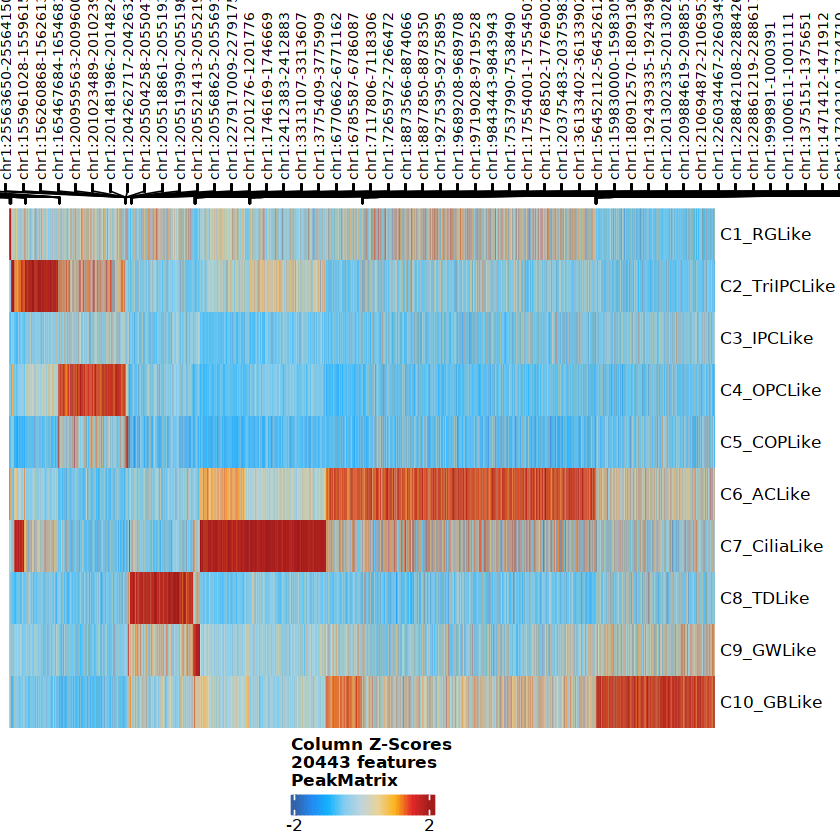

In [7]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [8]:
enrichATAC <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = malignant,
    peakAnnotation = "ATAC",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-2f1e163fe6ea91-Date-2024-09-10_Time-10-36-44.log
If there is an issue, please report to github with logFile!

2024-09-10 10:37:04 : Computing Enrichments 1 of 10, 0.331 mins elapsed.

2024-09-10 10:37:04 : Computing Enrichments 2 of 10, 0.337 mins elapsed.

2024-09-10 10:37:04 : Computing Enrichments 3 of 10, 0.342 mins elapsed.

2024-09-10 10:37:06 : Computing Enrichments 4 of 10, 0.364 mins elapsed.

2024-09-10 10:37:06 : Computing Enrichments 5 of 10, 0.367 mins elapsed.

2024-09-10 10:37:06 : Computing Enrichments 6 of 10, 0.371 mins elapsed.

2024-09-10 10:37:06 : Computing Enrichments 7 of 10, 0.374 mins elapsed.

2024-09-10 10:37:07 : Computing Enrichments 8 of 10, 0.379 mins elapsed.

2024-09-10 10:37:07 : Computing Enrichments 9 of 10, 0.382 mins elapsed.

2024-09-10 10:37:07 : Computing Enrichments 10 of 10, 0.387 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-2f1e163fe6ea91-Date-2024-09-10

In [9]:
heatmapATAC <- plotEnrichHeatmap(enrichATAC, n = 7, transpose = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2f1e1631658db3-Date-2024-09-10_Time-10-37-08.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



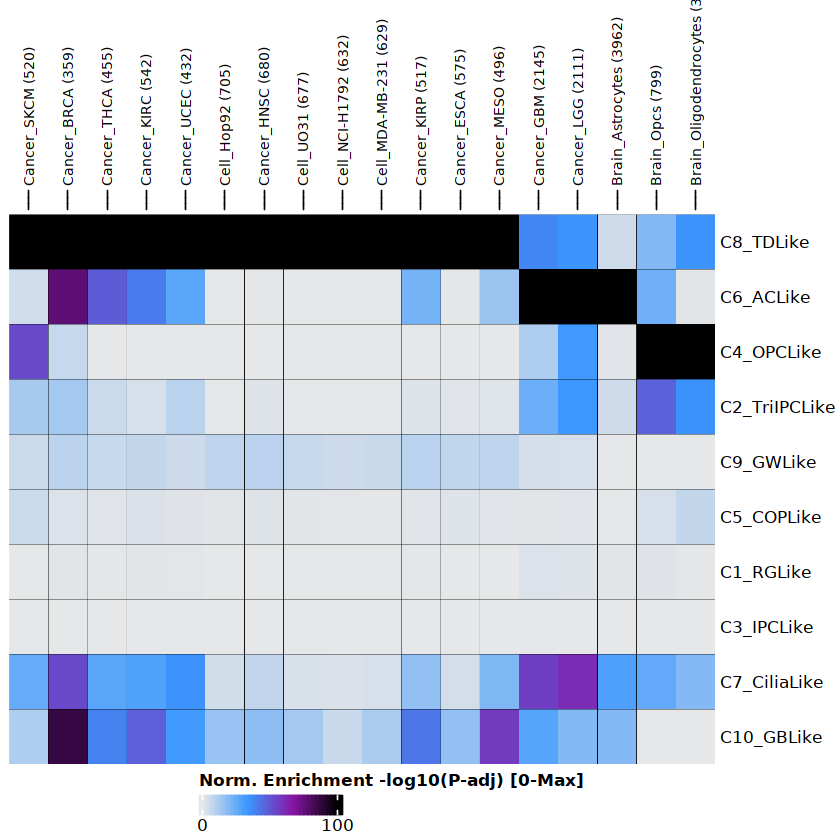

In [10]:
ComplexHeatmap::draw(heatmapATAC, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [15]:
heatmapATAC <- plotEnrichHeatmap(enrichATAC, n = 7, transpose = TRUE, 
                                clusterCols = FALSE,
                                 binaryClusterRows = TRUE)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2f1e1659902b71-Date-2024-09-10_Time-10-38-56.log
If there is an issue, please report to github with logFile!

Adding Annotations..

Preparing Main Heatmap..



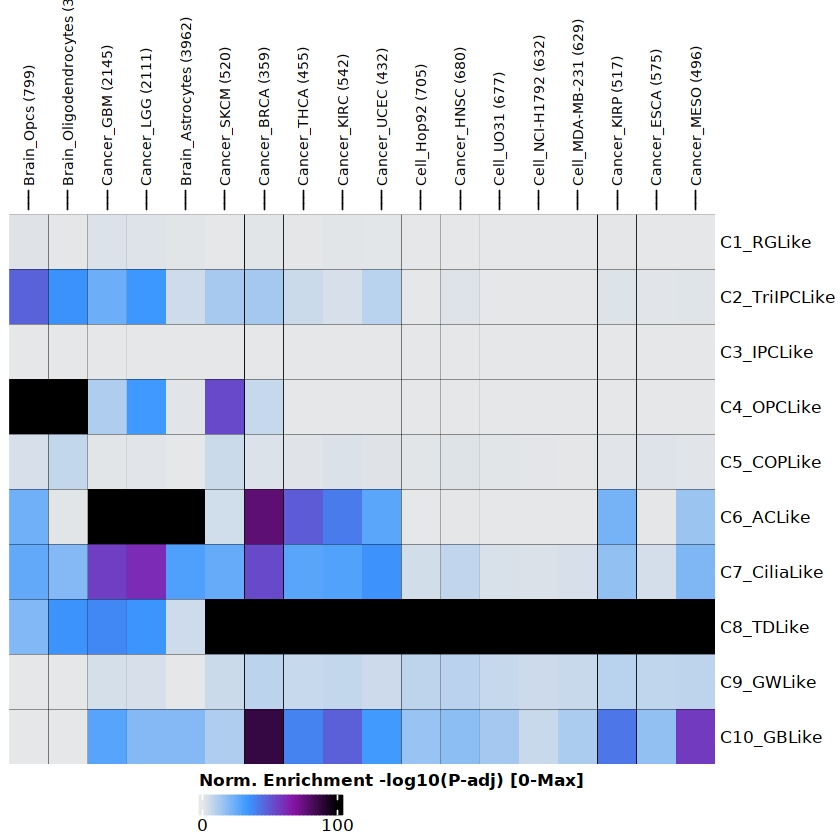

In [16]:
ComplexHeatmap::draw(heatmapATAC, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [17]:
plotPDF(heatmapATAC, name = "ATAC-Enriched-Marker-Heatmap", width = 8, height = 6, 
        ArchRProj = malignant, addDOC = FALSE)

Plotting ComplexHeatmap!

